In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap


In [3]:
df = pd.read_csv("/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv")
print(df.shape)
df.head()


(7728394, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract time features
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month

# Drop rows with missing location data
df = df.dropna(subset=['Start_Lat', 'Start_Lng'])

# Check missing values
df.isnull().sum()


ID                             0
Source                         0
Severity                       0
Start_Time                743166
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

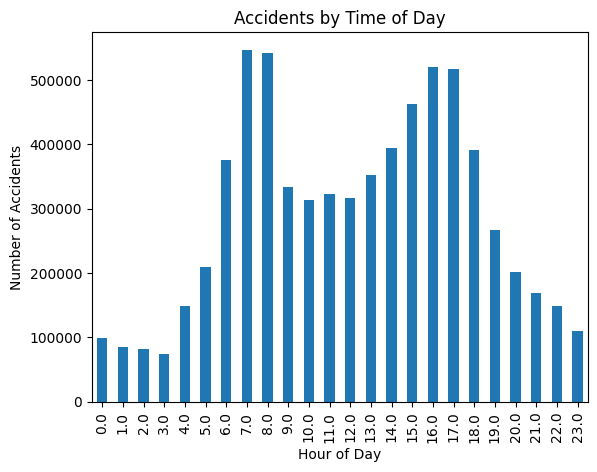

In [5]:
plt.figure()
df['Hour'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Time of Day")
plt.show()


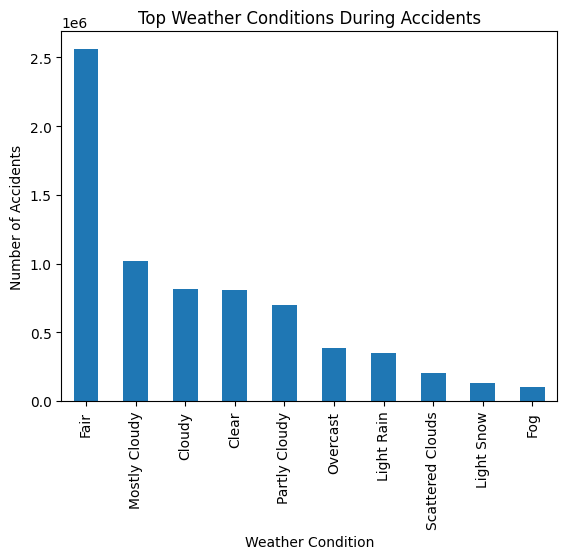

In [6]:
plt.figure()
df['Weather_Condition'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.title("Top Weather Conditions During Accidents")
plt.show()


In [8]:
def road_condition(row):
    if pd.notna(row['Precipitation(in)']) and row['Precipitation(in)'] > 0:
        return 'Wet Road'
    else:
        return 'Dry Road'

df['Road_Condition_Derived'] = df.apply(road_condition, axis=1)


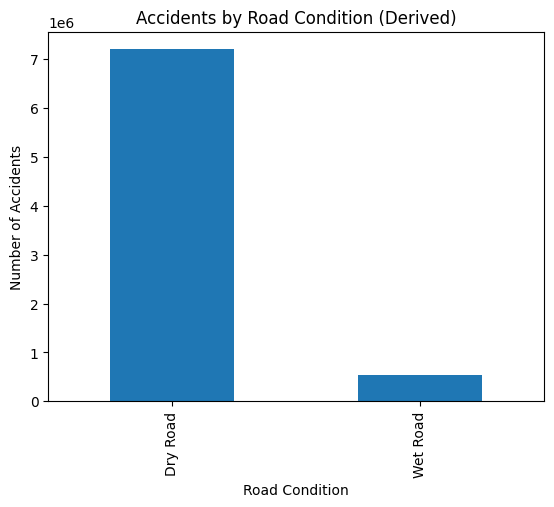

In [9]:
plt.figure()
df['Road_Condition_Derived'].value_counts().plot(kind='bar')
plt.xlabel("Road Condition")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Road Condition (Derived)")
plt.show()


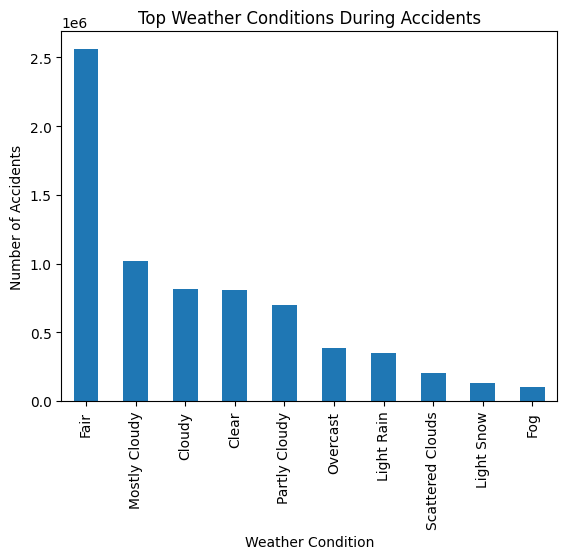

In [10]:
plt.figure()
df['Weather_Condition'].dropna().value_counts().head(10).plot(kind='bar')
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.title("Top Weather Conditions During Accidents")
plt.show()


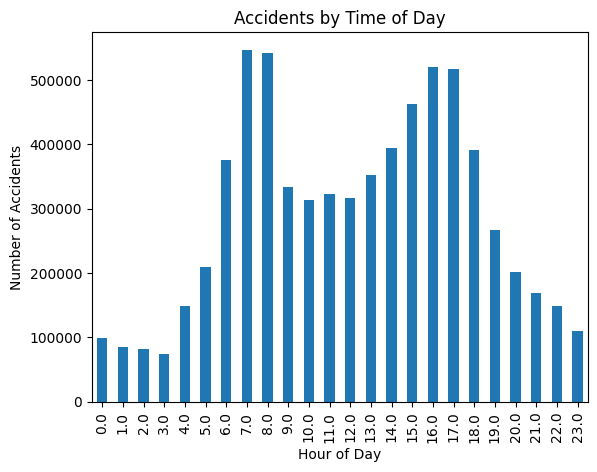

In [11]:
plt.figure()
df['Hour'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Time of Day")
plt.show()


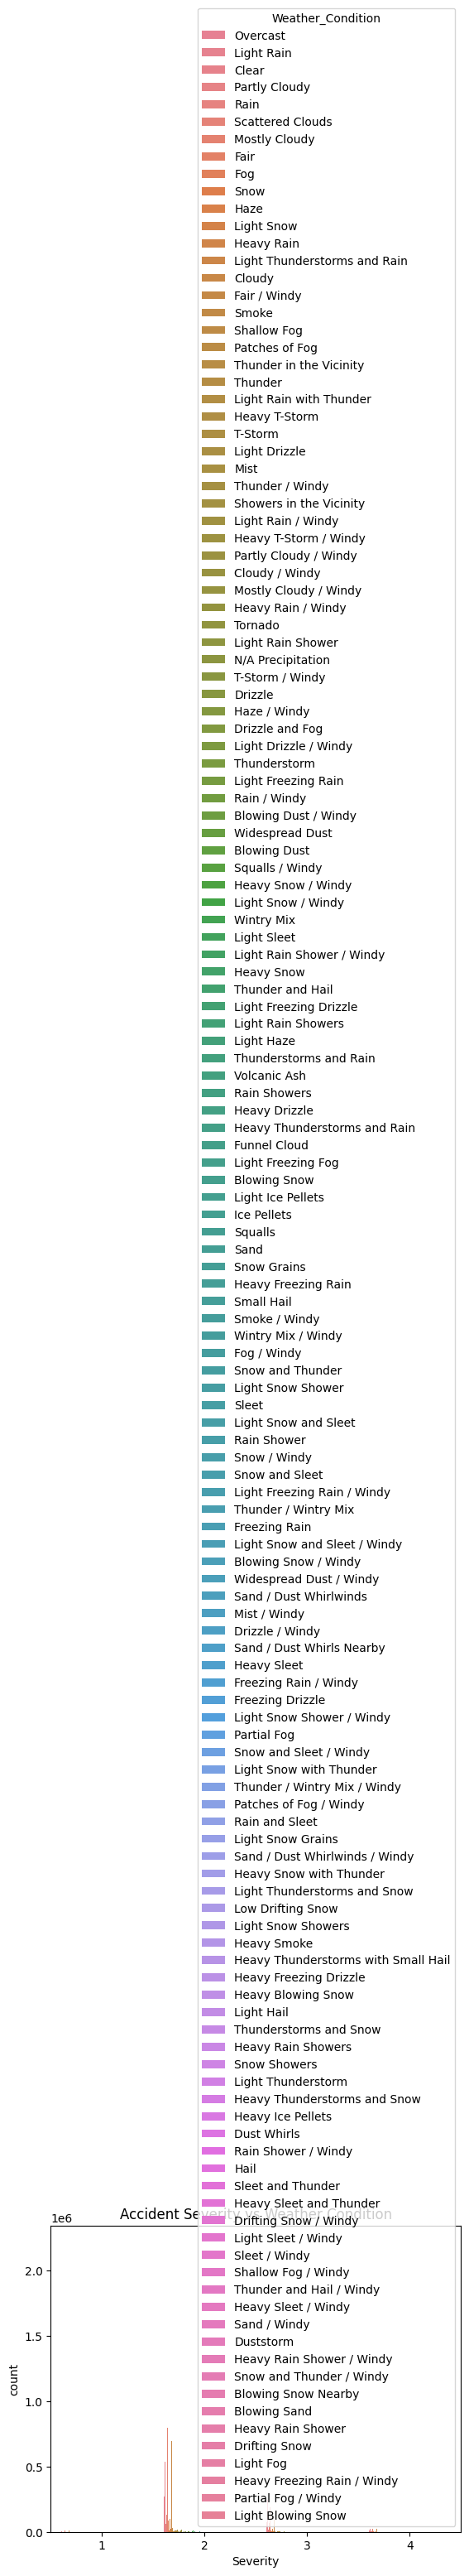

In [12]:
plt.figure()
sns.countplot(x='Severity', hue='Weather_Condition', data=df)
plt.title("Accident Severity vs Weather Condition")
plt.show()


In [13]:
# Create base map
map_usa = folium.Map(location=[39.5, -98.35], zoom_start=5)

# Prepare heatmap data
heat_data = list(zip(df['Start_Lat'], df['Start_Lng']))

# Add heatmap
HeatMap(heat_data, radius=8).add_to(map_usa)

# Save map
map_usa.save("Accident_Hotspots.html")


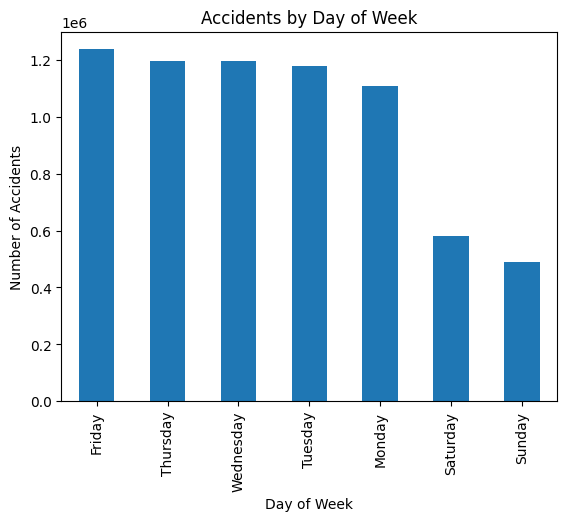

In [14]:
plt.figure()
df['Day'].value_counts().plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Day of Week")
plt.show()


In [16]:
print("• Accidents peak during evening and night hours")
print("• Poor weather increases accident frequency")
print("• Wet roads are a major contributing factor")
print("• Hotspots are concentrated near highways and urban areas")


• Accidents peak during evening and night hours
• Poor weather increases accident frequency
• Wet roads are a major contributing factor
• Hotspots are concentrated near highways and urban areas
